# Notebook 01 — Exploratory Data Analysis (EDA)
## AI-Powered Credit Risk Analyzer
**Dataset:** German Credit Risk (Kaggle / UCI)  
**Integrante 1:** Datos + EDA + Preprocessing  
**Objetivo:** Explorar y entender el dataset antes de modelar.

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Carga del dataset

In [2]:
df = pd.read_csv('../data/raw/german_credit_data.csv', index_col=0)

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Filas: 1000 | Columnas: 10


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## 3. Inspección general

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [4]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
# Valores nulos
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': nulls_pct})
print('Valores nulos por columna:')
null_df[null_df['Nulos'] > 0]

Valores nulos por columna:


,Nulos,Porcentaje (%)
Checking account,394,39.4
Saving accounts,183,18.3


> **Nota:** `Saving accounts` tiene ~18.3% de nulos y `Checking account` tiene ~39.4% de nulos. Estos serán tratados en el notebook de preprocessing.

## 4. Variable objetivo: `Risk`

Distribución de la variable objetivo:
      Conteo  Porcentaje (%)
Risk                        
good     700            70.0
bad      300            30.0


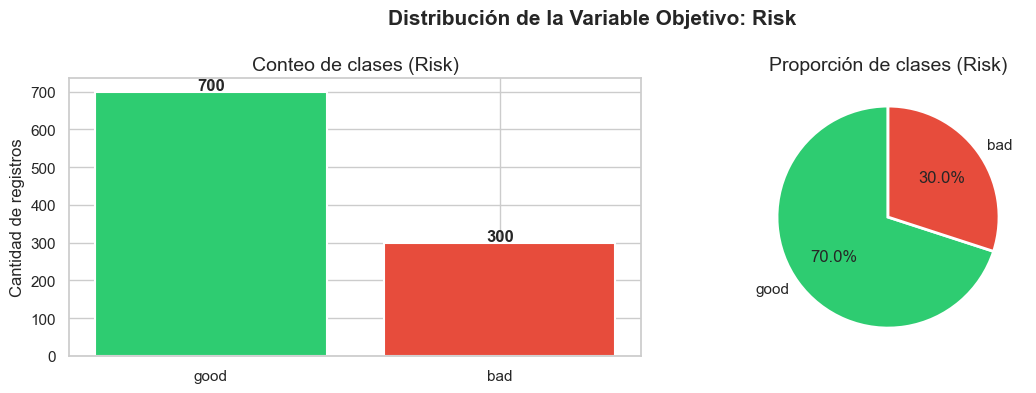


⚠️  El dataset está DESBALANCEADO: 70% good vs 30% bad.
   → Comunicar al Integrante 2 para manejo en el modelo (class_weight o SMOTE).


In [13]:
risk_counts = df['Risk'].value_counts()
risk_pct = df['Risk'].value_counts(normalize=True) * 100

print('Distribución de la variable objetivo:')
print(pd.DataFrame({'Conteo': risk_counts, 'Porcentaje (%)': risk_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Conteo de clases (Risk)')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de clases (Risk)')

plt.suptitle('Distribución de la Variable Objetivo: Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  El dataset está DESBALANCEADO: 70% good vs 30% bad.')
print('   → Comunicar al Integrante 2 para manejo en el modelo (class_weight o SMOTE).')

## 5. Variables numéricas

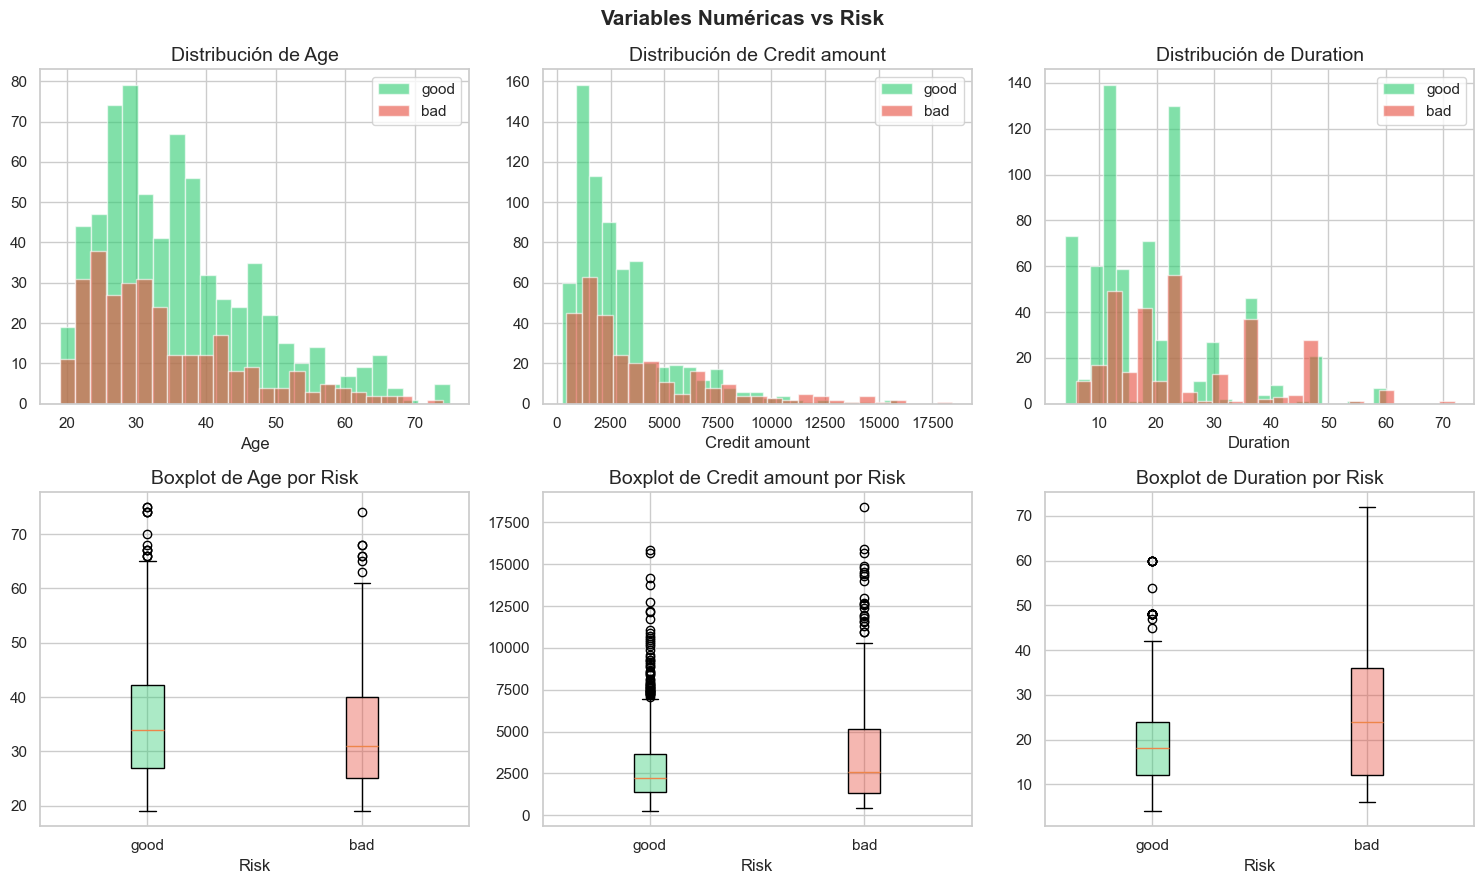

In [8]:
num_cols = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(num_cols):
    # Histograma por clase
    for risk, color in zip(['good', 'bad'], ['#2ecc71', '#e74c3c']):
        axes[0, i].hist(df[df['Risk'] == risk][col], bins=25, alpha=0.6,
                        color=color, label=risk, edgecolor='white')
    axes[0, i].set_title(f'Distribución de {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot por clase
    good_vals = df[df['Risk'] == 'good'][col]
    bad_vals = df[df['Risk'] == 'bad'][col]
    bp = axes[1, i].boxplot([good_vals, bad_vals], labels=['good', 'bad'],
                             patch_artist=True, notch=False)
    bp['boxes'][0].set_facecolor('#2ecc7166')
    bp['boxes'][1].set_facecolor('#e74c3c66')
    axes[1, i].set_title(f'Boxplot de {col} por Risk')
    axes[1, i].set_xlabel('Risk')

plt.suptitle('Variables Numéricas vs Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plots/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Estadísticas por clase
print('Estadísticas de variables numéricas por clase (Risk):')
df.groupby('Risk')[num_cols].agg(['mean', 'median', 'std']).round(2)

Estadísticas de variables numéricas por clase (Risk):


Age               Credit amount                  Duration         \
       mean median    std          mean  median      std     mean median   
Risk                                                                       
bad   33.96   31.0  11.22       3938.13  2574.5  3535.82    24.86   24.0   
good  36.22   34.0  11.38       2985.46  2244.0  2401.47    19.21   18.0   

             
        std  
Risk         
bad   13.28  
good  11.08

## 6. Variables categóricas

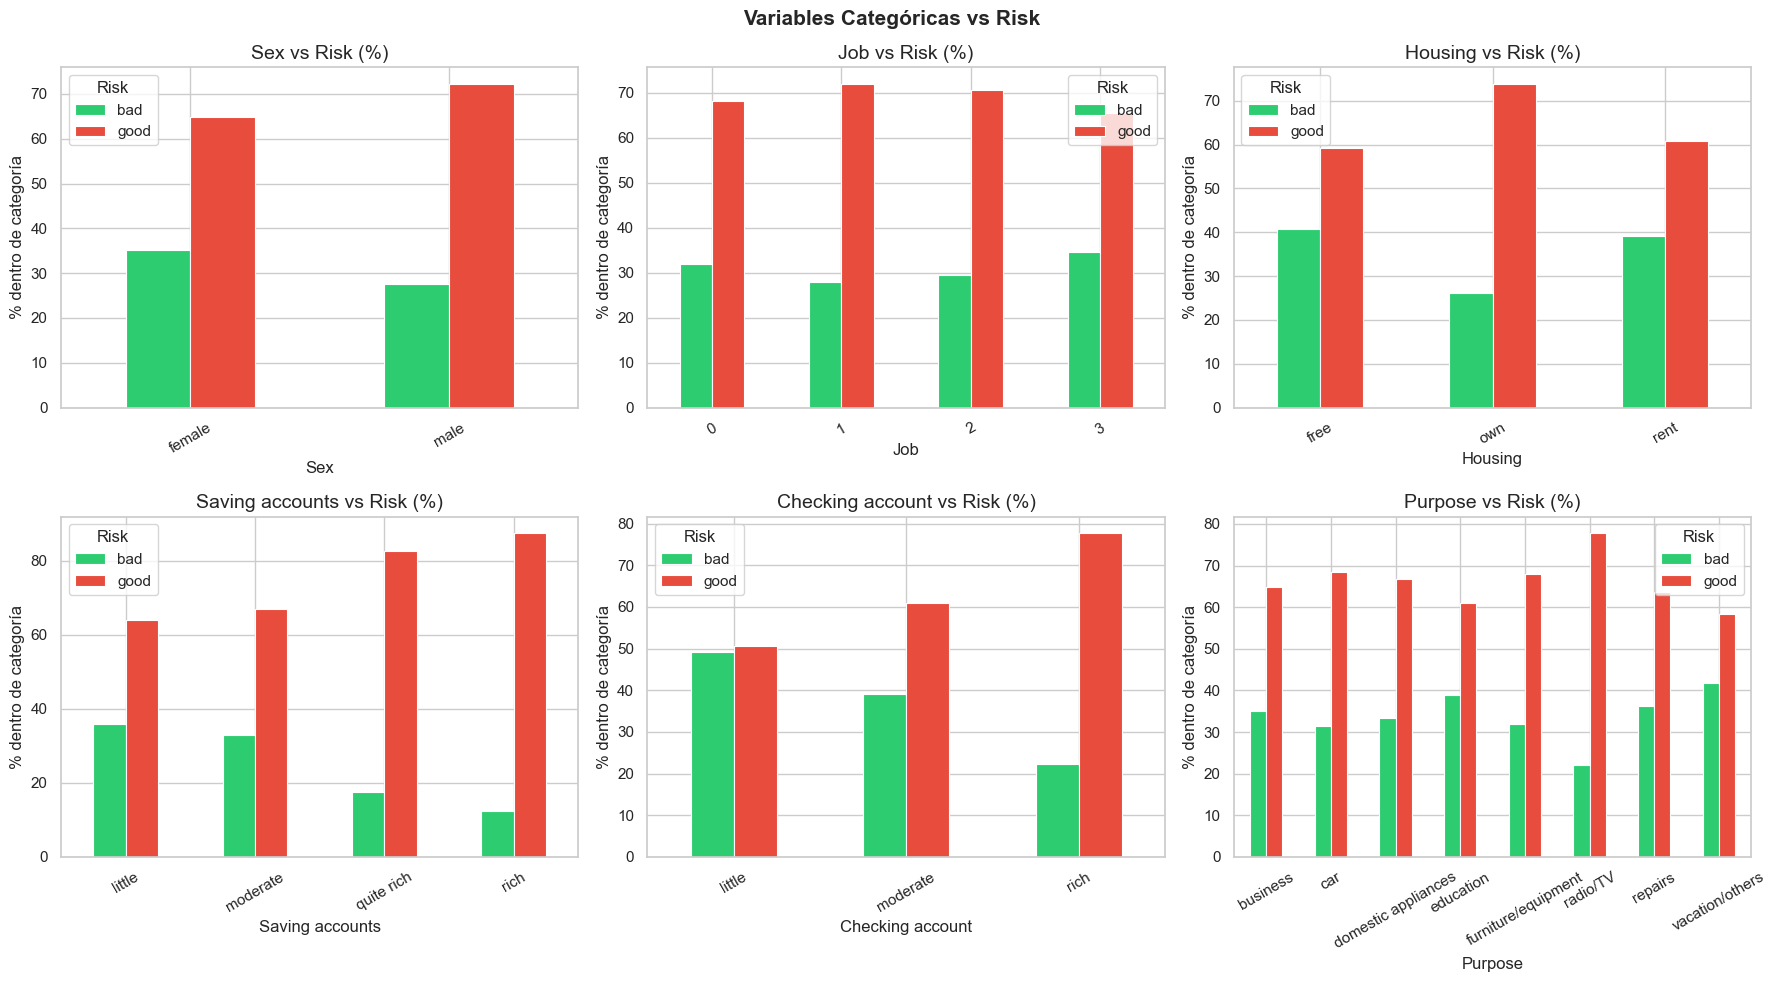

In [10]:
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Risk'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col} vs Risk (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% dentro de categoría')
    axes[i].legend(title='Risk')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Variables Categóricas vs Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plots/03_categorical_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Matriz de correlación (variables numéricas)

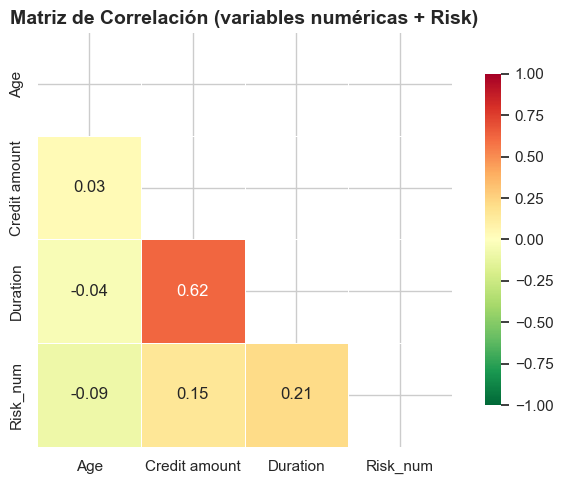

In [11]:
# Convertir Risk a numérico para incluirlo en la correlación
df_corr = df.copy()
df_corr['Risk_num'] = (df_corr['Risk'] == 'bad').astype(int)

corr_cols = num_cols + ['Risk_num']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación (variables numéricas + Risk)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plots/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de valores faltantes (detalle)

In [12]:
# ¿Los nulos están relacionados con el riesgo?
df['saving_null'] = df['Saving accounts'].isnull().astype(int)
df['checking_null'] = df['Checking account'].isnull().astype(int)

print('Risk cuando Saving accounts es nulo:')
print(df[df['saving_null'] == 1]['Risk'].value_counts(normalize=True).mul(100).round(2))

print('\nRisk cuando Checking account es nulo:')
print(df[df['checking_null'] == 1]['Risk'].value_counts(normalize=True).mul(100).round(2))

# Limpiar columnas auxiliares
df.drop(columns=['saving_null', 'checking_null'], inplace=True)

Risk cuando Saving accounts es nulo:
Risk
good    82.51
bad     17.49
Name: proportion, dtype: float64

Risk cuando Checking account es nulo:
Risk
good    88.32
bad     11.68
Name: proportion, dtype: float64


## 9. Insights y conclusiones del EDA

### Hallazgos principales:

1. **Desbalance de clases:** El dataset tiene 70% `good` y 30% `bad`. Es necesario aplicar estrategias de balanceo (SMOTE o `class_weight='balanced'`) durante el modelado.

2. **Duración del crédito:** Los préstamos clasificados como `bad` tienden a tener mayor duración (más meses). Mayor duración → mayor riesgo.

3. **Monto del crédito:** Los créditos de mayor monto están más asociados a la clase `bad`. Existe correlación positiva entre `Credit amount` y `Duration`.

4. **Cuentas de ahorro y corriente:** Alta proporción de nulos (~18% y ~39% respectivamente). Los registros con cuenta corriente nula tienden a ser de mayor riesgo, lo que sugiere que el nulo tiene significado informativo (posiblemente "sin cuenta").

5. **Housing y Sex:** Personas con vivienda `free` (sin pago) y mujeres presentan ligeramente mayor proporción de riesgo `bad`.

6. **Purpose:** Los préstamos para `vacation/others` y `education` tienen mayor proporción de riesgo malo comparados con `radio/TV` o `car`.
